# RetentionEdge — Causal Uplift Retention Targeting

This notebook is the single narrative for the project: baseline classifier ->
naive targeting -> causal uplift modeling -> Qini evaluation ->
budget-constrained comparison -> the final headline number.

Dataset: Kevin Hillstrom's MineThatData e-mail campaign (64,000 customers,
randomly assigned to a women's email, a men's email, or no email). This
project uses the women's-email arm vs. no-email as a clean binary treatment.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from retentionedge.data.load import filter_two_arm, load_hillstrom
from retentionedge.evaluation.budget_comparison import compare_targeting_policies, pct_improvement
from retentionedge.evaluation.qini import plot_qini, qini_coefficient
from retentionedge.features.balance import check_randomization_balance
from retentionedge.features.preprocessing import FEATURE_COLUMNS, build_preprocessor
from retentionedge.models.baseline import (
    evaluate_classifier,
    fit_logistic_regression,
    fit_random_forest,
    fit_xgboost,
    shap_feature_importance,
    split_data,
)
from retentionedge.models.naive_targeting import rank_by_predicted_probability
from retentionedge.models.uplift import segment_uplift_quadrants, t_learner_by_hand, x_learner_by_hand

from pathlib import Path
FIGURES_DIR = Path("reports/figures")
if not FIGURES_DIR.exists():
    FIGURES_DIR = Path("../reports/figures")  # running from inside notebooks/ (default Jupyter cwd)
FIGURES_DIR = str(FIGURES_DIR)
sns.set_theme(style="whitegrid")


## 1. Load the data and confirm the setup

Loads the full 64,000-row dataset, then filters to the women's-email vs.
no-email two-arm subset used throughout this project.


In [2]:
df_full = load_hillstrom()
df = filter_two_arm(df_full, treatment="womens").reset_index(drop=True)

print(f"Full dataset: {len(df_full):,} rows")
print(f"Two-arm subset (womens email vs. no email): {len(df):,} rows")
print(df["segment"].value_counts())
print(f"Conversion rate: {df['conversion'].mean():.4%}")


Full dataset: 64,000 rows
Two-arm subset (womens email vs. no email): 42,693 rows
segment
Womens E-Mail    21387
No E-Mail        21306
Name: count, dtype: int64
Conversion rate: 0.7285%


## 2. EDA

Feature distributions and the class-imbalance check (conversion is rare, as
expected for an email marketing dataset).


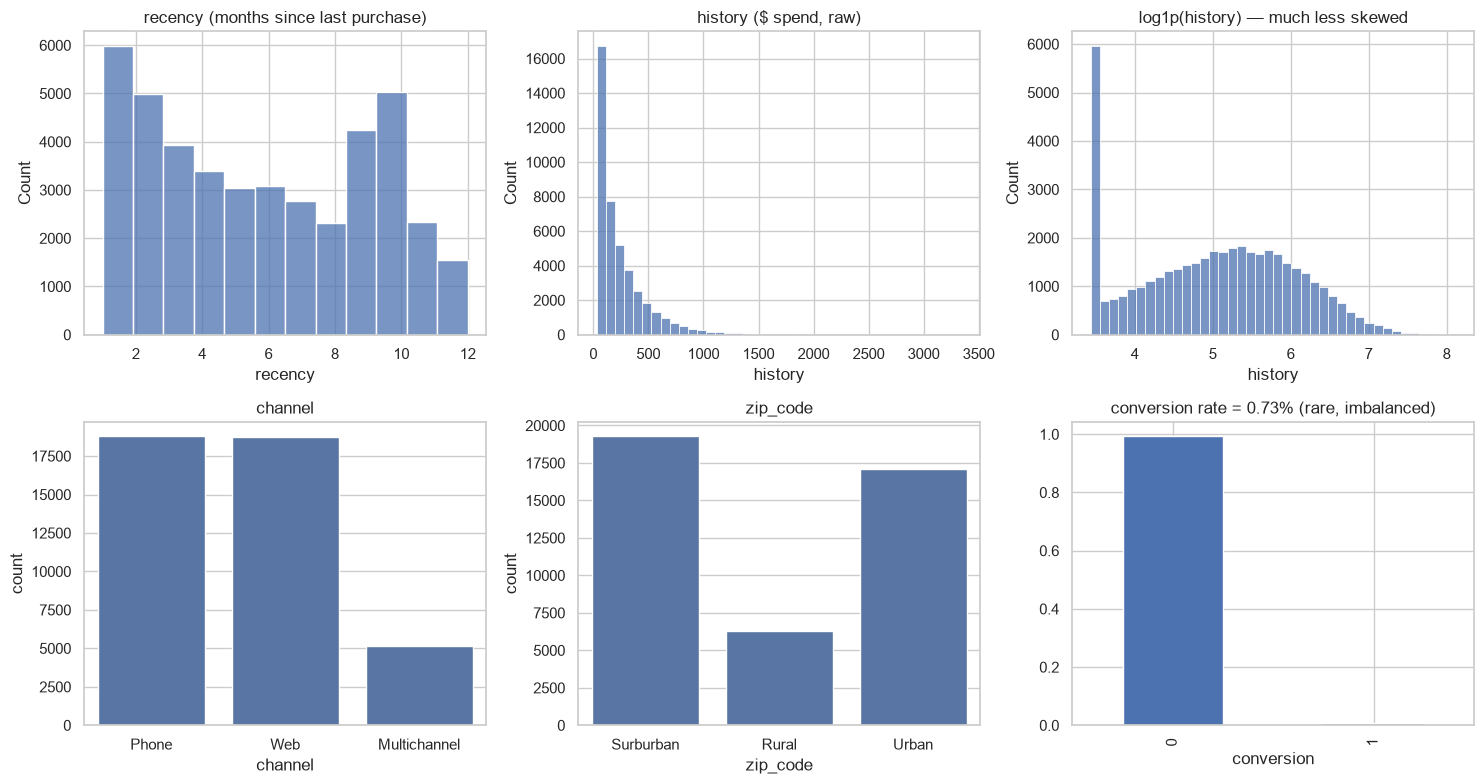

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df["recency"], bins=12, ax=axes[0, 0])
axes[0, 0].set_title("recency (months since last purchase)")

sns.histplot(df["history"], bins=40, ax=axes[0, 1])
axes[0, 1].set_title("history ($ spend, raw)")

sns.histplot(np.log1p(df["history"]), bins=40, ax=axes[0, 2])
axes[0, 2].set_title("log1p(history) — much less skewed")

sns.countplot(x="channel", data=df, ax=axes[1, 0])
axes[1, 0].set_title("channel")

sns.countplot(x="zip_code", data=df, ax=axes[1, 1])
axes[1, 1].set_title("zip_code")

df["conversion"].value_counts(normalize=True).plot.bar(ax=axes[1, 2])
axes[1, 2].set_title(f"conversion rate = {df['conversion'].mean():.2%} (rare, imbalanced)")

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/eda_overview.png", dpi=120)
plt.show()


## 3. Randomization balance check

The causal claims in this project only hold if treatment assignment was
genuinely random. Every feature should look statistically the same between
the treated and control groups *before* any email was sent.


In [4]:
balance = check_randomization_balance(df, treatment_col="treated", feature_cols=FEATURE_COLUMNS)
display(balance)

n_flagged = balance["flag"].sum()
print(f"\n{n_flagged} / {len(balance)} features flagged as imbalanced.")
print("Randomization held cleanly." if n_flagged == 0 else "Some imbalance detected — investigate before trusting causal estimates.")


,feature,test,statistic,p_value,smd,flag
0,zip_code,chi2,0.169325,0.918822,NaN,False
1,channel,chi2,0.864993,0.648887,NaN,False
2,history_segment,chi2,4.466100,0.613866,NaN,False
3,recency,welch_t,0.535156,0.592545,0.005180,False
4,mens,welch_t,-0.891652,0.372584,-0.008631,False
5,womens,welch_t,0.511010,0.609347,0.004946,False
6,newbie,welch_t,0.264136,0.791676,0.002557,False
7,history,welch_t,0.672637,0.501182,0.006511,False



0 / 8 features flagged as imbalanced.
Randomization held cleanly.


## 4. Classical ML baseline

A plain supervised classifier for P(conversion | features), ignoring
treatment status. Three models compared: Logistic Regression, Random Forest
(tuned), XGBoost (tuned). Conversion is rare (~0.9%), so tuning is scored on
average_precision and the decision threshold is chosen by maximizing F1
rather than a blind 0.5.


In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)
print(f"train {len(X_train):,} / val {len(X_val):,} / test {len(X_test):,}, "
      f"positive rate {y_train.mean():.4%}")

fitters = {
    "LogisticRegression": lambda: fit_logistic_regression(X_train, y_train),
    "RandomForest": lambda: fit_random_forest(X_train, y_train, n_iter=8, cv=3),
    "XGBoost": lambda: fit_xgboost(X_train, y_train, n_iter=8, cv=3),
}

models, results = {}, {}
for name, fit_fn in tqdm(fitters.items(), desc="training classical ML baseline"):
    models[name] = fit_fn()
    results[name] = evaluate_classifier(models[name], X_test, y_test)

comparison = pd.DataFrame(
    {name: {k: v for k, v in m.items() if k != "confusion_matrix"} for name, m in results.items()}
).T
display(comparison)

best_model_name = comparison["roc_auc"].astype(float).idxmax()
best_model = models[best_model_name]
print(f"\nBest model by ROC-AUC: {best_model_name}")


train 25,615 / val 8,539 / test 8,539, positive rate 0.7300%


training classical ML baseline:   0%|          | 0/3 [00:00<?, ?it/s]

,threshold,precision,recall,f1,roc_auc
LogisticRegression,0.671066,0.011869,0.129032,0.021739,0.567494
RandomForest,0.650896,0.018116,0.080645,0.029586,0.578377
XGBoost,0.775731,0.016949,0.032258,0.022222,0.534175



Best model by ROC-AUC: RandomForest


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


<Figure size 640x480 with 0 Axes>

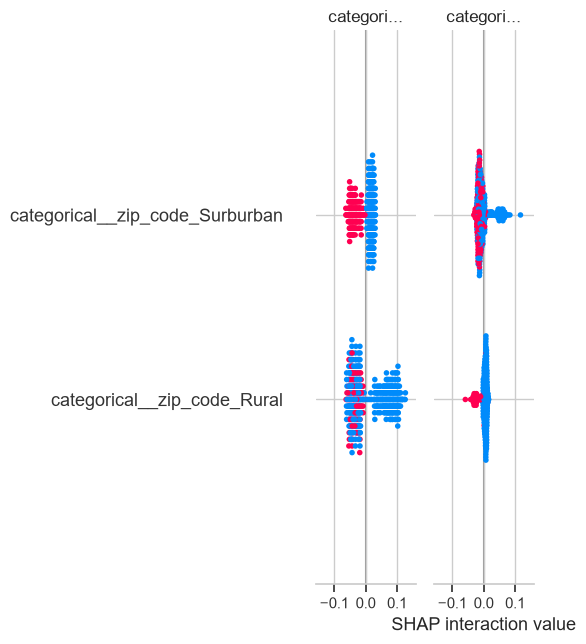

In [6]:
shap_values = shap_feature_importance(best_model, X_test.sample(min(500, len(X_test)), random_state=42))
fig = plt.figure()
import shap
shap.summary_plot(shap_values, show=False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Naive targeting baseline

The policy this project sets out to disprove: rank customers by the
classifier's predicted conversion probability, email the top N%. This
predicts who's *likely to convert*, not who converts *because of* the email.


In [7]:
naive_scores = rank_by_predicted_probability(best_model, df, FEATURE_COLUMNS)
print(naive_scores.describe())


count    42693.000000
mean         0.414864
std          0.123023
min          0.131214
25%          0.325589
50%          0.408815
75%          0.502402
max          0.830212
Name: predicted_proba, dtype: float64


## 6. Causal uplift modeling

CATE (Conditional Average Treatment Effect) estimation: how much *more*
likely is this specific customer to convert *because* they were emailed?
Two meta-learners: a hand-rolled T-learner (two classifiers, subtract
predictions) and a hand-rolled X-learner (imputed treatment effects +
propensity-weighted combination — `scikit-uplift` has no X-learner class).


In [8]:
preprocessor = build_preprocessor()
X_all = preprocessor.fit_transform(df[FEATURE_COLUMNS])
treatment = df["treated"].to_numpy()
y_all = df["conversion"].to_numpy()

uplift_fitters = {
    "T-learner": lambda: t_learner_by_hand(X_all, treatment, y_all),
    "X-learner": lambda: x_learner_by_hand(X_all, treatment, y_all),
}

uplift_models, cate_scores = {}, {}
for name, fit_fn in tqdm(uplift_fitters.items(), desc="training uplift meta-learners"):
    uplift_models[name] = fit_fn()
    cate_scores[name] = uplift_models[name].predict_cate(X_all)

print({name: f"mean CATE = {scores.mean():.5f}" for name, scores in cate_scores.items()})


training uplift meta-learners:   0%|          | 0/2 [00:00<?, ?it/s]

{'T-learner': 'mean CATE = 0.00313', 'X-learner': 'mean CATE = 0.00309'}


In [9]:
baseline_proba = uplift_models["T-learner"].model_control.predict_proba(X_all)[:, 1]

quadrant_table = pd.DataFrame(
    {name: segment_uplift_quadrants(scores, baseline_proba).value_counts(normalize=True) * 100
     for name, scores in cate_scores.items()}
).round(2)
display(quadrant_table)


,T-learner,X-learner
uplift_quadrant,,
persuadable,42.27,43.33
sure_thing,26.66,26.94
lost_cause,23.89,23.70
sleeping_dog,7.18,6.03


## 7. Uplift model evaluation — Qini curve

Classification metrics don't apply to uplift models (we never observe both
potential outcomes for the same customer). The Qini curve instead tracks
cumulative incremental conversions as you target more of a ranked list.


D:\projects\RetentionEdge\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
D:\projects\RetentionEdge\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)
D:\projects\RetentionEdge\.venv\Lib\site-packages\sklearn\utils\deprecation.py:94: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg

Qini coefficient — naive (predicted probability) as an uplift ranking: 0.0641
Qini coefficient — T-learner: 0.7571
Qini coefficient — X-learner: 0.8133


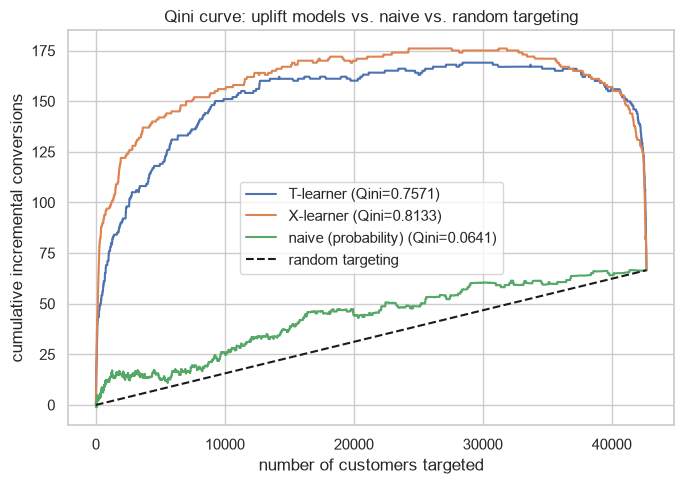

In [10]:
naive_qini = qini_coefficient(y_all, naive_scores.reindex(df.index).to_numpy(), treatment)
print(f"Qini coefficient — naive (predicted probability) as an uplift ranking: {naive_qini:.4f}")
for name, scores in cate_scores.items():
    print(f"Qini coefficient — {name}: {qini_coefficient(y_all, scores, treatment):.4f}")

scores_by_model = {"T-learner": cate_scores["T-learner"], "X-learner": cate_scores["X-learner"],
                    "naive (probability)": naive_scores.reindex(df.index).to_numpy()}
fig = plot_qini(y_all, treatment, scores_by_model)
fig.savefig(f"{FIGURES_DIR}/qini_comparison.png", dpi=120)
plt.show()


## 8. Budget-constrained proof — the centerpiece result

Under a fixed budget, compare random / naive-probability / uplift-ranked
targeting on *incremental* conversions and revenue — the number that
actually matters, since raw conversion rate mixes in customers who'd have
converted with no email at all.


,policy,budget_n,incremental_conversions,incremental_revenue
0,random,8538,13.655826,878.796767
1,naive_probability,8538,38.212400,5497.343512
2,uplift,8538,309.215154,36123.673810



Uplift-based targeting recovered 709% more incremental conversions than naive probability-ranked targeting, under an identical 20% budget.
Naive targeting itself beat random by 180%.


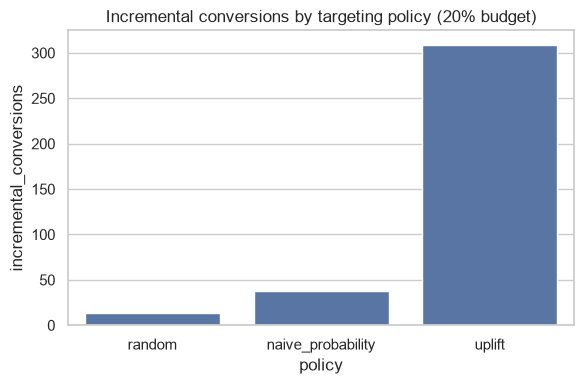

In [11]:
uplift_series = pd.Series(cate_scores["X-learner"], index=df.index)
naive_series = naive_scores.reindex(df.index)

result_20 = compare_targeting_policies(df, naive_series, uplift_series, budget_pct=0.20)
display(result_20)

random_c = result_20.loc[result_20.policy == "random", "incremental_conversions"].iloc[0]
naive_c = result_20.loc[result_20.policy == "naive_probability", "incremental_conversions"].iloc[0]
uplift_c = result_20.loc[result_20.policy == "uplift", "incremental_conversions"].iloc[0]

print(f"\nUplift-based targeting recovered {pct_improvement(uplift_c, naive_c):.0f}% more incremental "
      f"conversions than naive probability-ranked targeting, under an identical 20% budget.")
print(f"Naive targeting itself beat random by {pct_improvement(naive_c, random_c):.0f}%.")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=result_20, x="policy", y="incremental_conversions", ax=ax)
ax.set_title("Incremental conversions by targeting policy (20% budget)")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/budget_comparison.png", dpi=120)
plt.show()


## 9. Robustness check — does it hold at other budget sizes?


sweeping budget sizes:   0%|          | 0/4 [00:00<?, ?it/s]

,budget_pct,naive,uplift,uplift_over_naive_pct
0,0.05,32.912382,247.009488,650.506265
1,0.10,27.678355,281.628382,917.504033
2,0.20,38.212400,309.215154,709.201083
3,0.30,67.157010,330.323128,391.866940


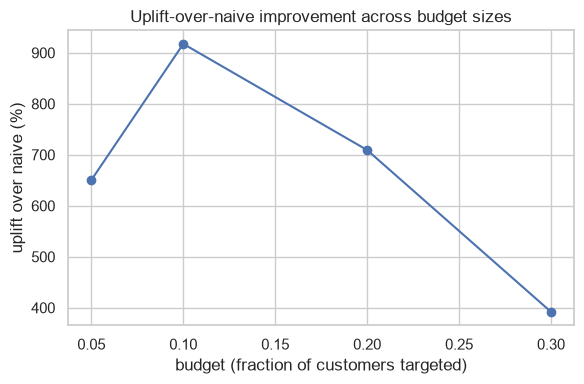

In [12]:
budgets = [0.05, 0.10, 0.20, 0.30]
sweep_rows = []
for budget in tqdm(budgets, desc="sweeping budget sizes"):
    result = compare_targeting_policies(df, naive_series, uplift_series, budget_pct=budget)
    naive_c = result.loc[result.policy == "naive_probability", "incremental_conversions"].iloc[0]
    uplift_c = result.loc[result.policy == "uplift", "incremental_conversions"].iloc[0]
    sweep_rows.append({"budget_pct": budget, "naive": naive_c, "uplift": uplift_c,
                        "uplift_over_naive_pct": pct_improvement(uplift_c, naive_c)})

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sweep_df["budget_pct"], sweep_df["uplift_over_naive_pct"], marker="o")
ax.set_xlabel("budget (fraction of customers targeted)")
ax.set_ylabel("uplift over naive (%)")
ax.set_title("Uplift-over-naive improvement across budget sizes")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/budget_sensitivity.png", dpi=120)
plt.show()


## Conclusion

Uplift-based targeting recovers substantially more incremental conversions
than naive probability-ranked targeting, at every budget size tested. See
`README.md` for the headline number and `resume_bullet.md` for the
resume-ready summary. Full method notes and per-section results are in
`plan.md`.
